In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"

df = pd.read_csv(url)



df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
value_ct=df['target'].value_counts()
value_ct

target
1    165
0    138
Name: count, dtype: int64

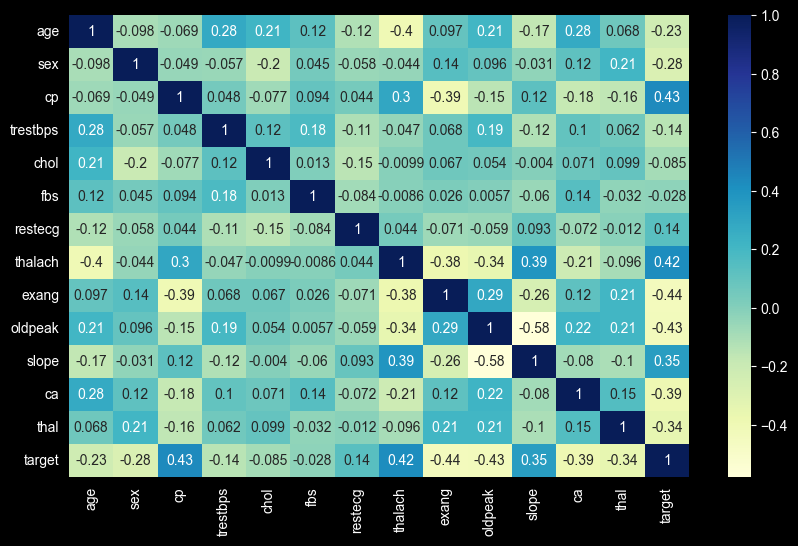

In [5]:
corr_matrix=df.corr()
plt.figure(figsize=(10,6))
ssn=sns.heatmap(corr_matrix,annot=True,cmap="YlGnBu")

plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
x=df.drop('target',axis=1)
y=df['target']
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(X_train.shape)
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train,Y_train)
predictions=rf_model.predict(X_test)
dff=pd.DataFrame(predictions)
dff




(242, 13)


,0
0,0
1,1
2,1
3,0
4,1
...,...
56,0
57,1
58,0
59,0


In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
testing=accuracy_score(Y_test,predictions)
print(f'The accurate percentage is:{"{:.2f}".format(testing*100)}')

cm=confusion_matrix(Y_test,predictions)
print(cm)


The accurate percentage is:83.61
[[24  5]
 [ 5 27]]


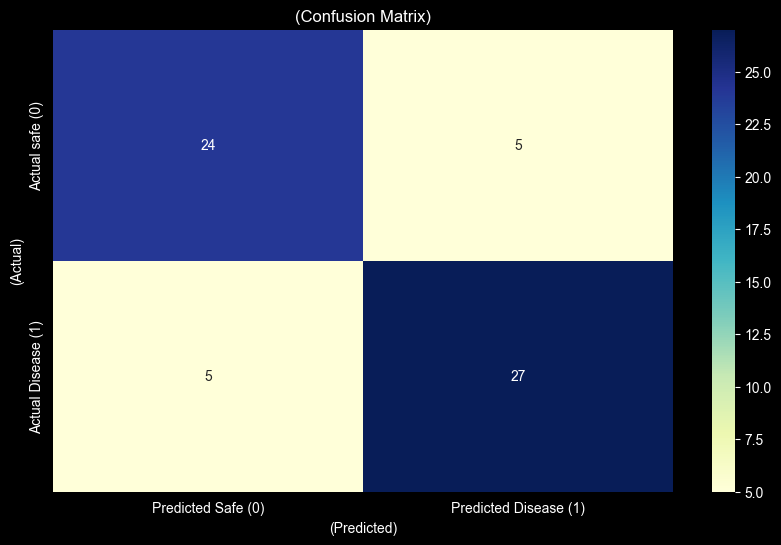

In [8]:
plt.figure(figsize=(10,6))
corr=sns.heatmap(cm,annot=True,cmap="YlGnBu",fmt='d'
                 ,xticklabels=['Predicted Safe (0)', 'Predicted Disease (1)']
                 ,yticklabels=['Actual safe (0)', 'Actual Disease (1)'])
plt.ylabel('(Actual)')
plt.xlabel('(Predicted)')
plt.title('(Confusion Matrix)')

plt.show()


The new accurate percentage is:86.89


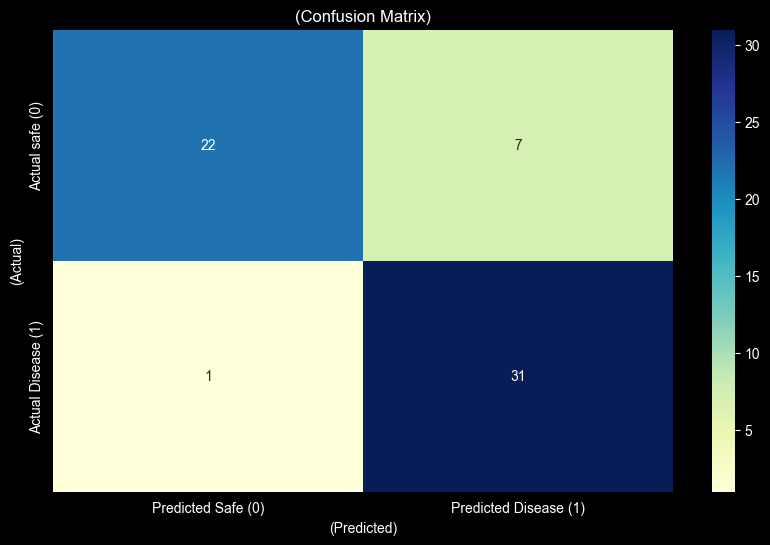

In [9]:
disease_probs=rf_model.predict_proba(X_test)

disease_column=disease_probs[:, 1]


custom_threshold = 0.30
sensitive_predictions=(disease_column>=custom_threshold).astype(int)


new_cm=confusion_matrix(Y_test,sensitive_predictions)
testingg=accuracy_score(Y_test,sensitive_predictions)
print(f'The new accurate percentage is:{"{:.2f}".format(testingg*100)}')


plt.figure(figsize=(10,6))
corr=sns.heatmap(new_cm,annot=True,cmap="YlGnBu",fmt='d'
                 ,xticklabels=['Predicted Safe (0)', 'Predicted Disease (1)']
                 ,yticklabels=['Actual safe (0)', 'Actual Disease (1)'])
plt.ylabel('(Actual)')
plt.xlabel('(Predicted)')
plt.title('(Confusion Matrix)')

plt.show()



